<a href="https://colab.research.google.com/github/RecursionAndIteration/AIcourse/blob/main/RegresjaLiniowa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
def srednia(l):
  suma=0
  for liczba in l:
    suma=suma+liczba
  srednia=suma/len(l)
  return srednia

lista=[1,2,3,4,5]
print(srednia(lista))

17.333333333333332


In [ ]:
def mediana(l):
  l.sort()
  if len(l)%2==0:
    mediana=(l[len(l)/2]+l[len(1)/2-1])/2
  else:
    mediana=l[len(l)//2]
  return mediana

lista=[1,2,3,4,5,6,7]
print(mediana(lista))

4


In [ ]:
def moda(li):
  licznik={i: li.count(i) for i in set(li)}
  max_czestosc = max(licznik.values())
  moda = [key for key, value in licznik.items() if value == max_czestosc]
  return moda

lista=[1,1,2,2,3,4,5,6,7]
print(moda(lista))

[1, 2]


In [ ]:
import statistics as stat
import matplotlib.pyplot as plt

def variance(group):
  sr = stat.mean(group)
  variance = sum((x-sr)**2 for x in group) / (len(group)-1)
  return variance, sr


pajaki = [48, 49, 51, 52]
ender_dragony = [0, 0, 100, 100]
szkielety = [10, 30, 70, 90]
zombie = [49, 50, 50, 51]

groups = {
 "Pająki Parkour Masterzy": pajaki,
 "Ender Dragony z Ohio": ender_dragony,
 "Szkielety Beznogi Snajperzy": szkielety,
 "Zombie Ziomby": zombie
}

variances = {}
sr_s={}

for name, group in groups.items():
  war , sr = variance(group)
  variances[name] = war
  sr_s[name]=sr
  print(f"{name} srednia - {sr_s[name]}")
  print(f"{name} wariancja - {variances[name]}")

Pająki Parkour Masterzy srednia - 50
Pająki Parkour Masterzy wariancja - 3.3333333333333335
Ender Dragony z Ohio srednia - 50
Ender Dragony z Ohio wariancja - 3333.3333333333335
Szkielety Beznogi Snajperzy srednia - 50
Szkielety Beznogi Snajperzy wariancja - 1333.3333333333333
Zombie Ziomby srednia - 50
Zombie Ziomby wariancja - 0.6666666666666666


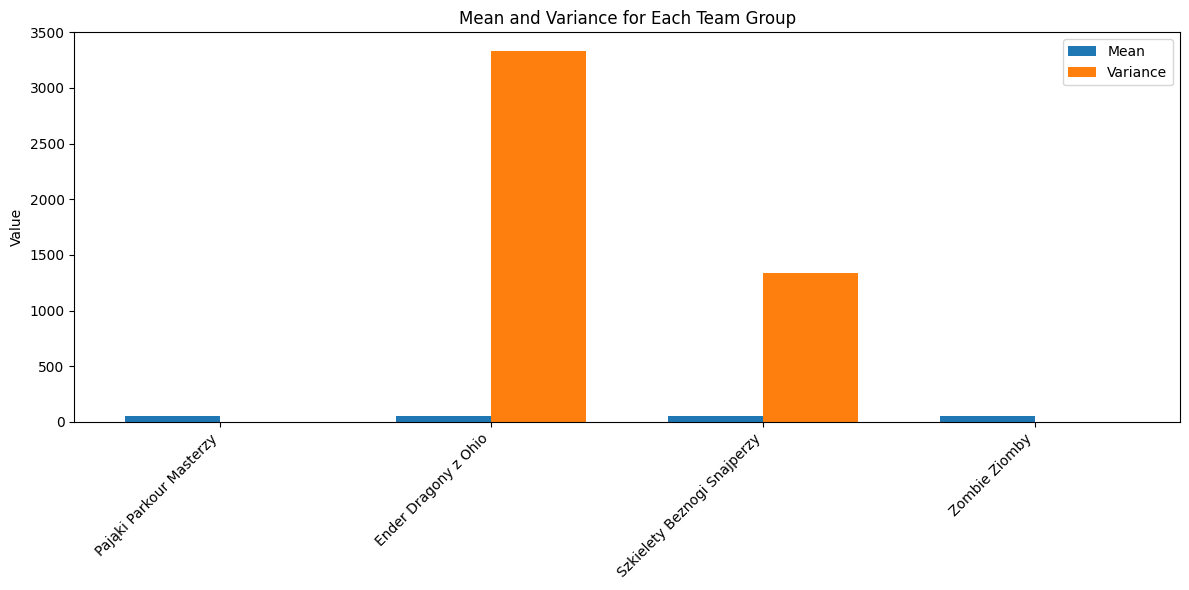

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

labels = list(groups.keys())
mean_values = list(sr_s.values())
variance_values = list(variances.values())

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
rects1 = ax.bar(x - width/2, mean_values, width, label='Mean')
rects2 = ax.bar(x + width/2, variance_values, width, label='Variance')

ax.set_ylabel('Value')
ax.set_title('Mean and Variance for Each Team Group')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.legend()

fig.tight_layout()
plt.show()

In [ ]:
hours_played = [1,2,3,4,5,6,7,8,9]
diamond_mined=[100,3,4,5,6,8,10,12,13]

def correlation(x,y):
  n = len(x)
  mean_x = sum(x)/n
  mean_y = sum(y)/n

  numerator = sum((value_x - mean_x)*(value_y - mean_y) for value_x, value_y in zip(x,y))

  denominator_x = sum((value_x - mean_x)**2 for value_x in x)
  denominator_y = sum((value_y - mean_y)**2 for value_y in y)

  denominator = (denominator_x*denominator_y)**0.5

  correlation = numerator/denominator
  return correlation



r_value = correlation(hours_played, diamond_mined)
print(f"Współczynnik korelacji: {r_value:.2f}")

Współczynnik korelacji: -0.45


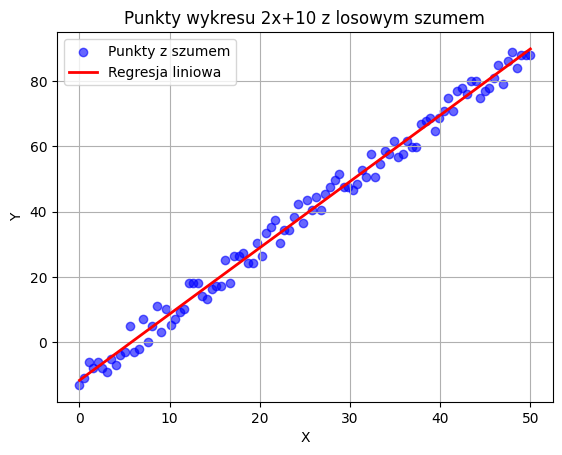

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

np.random.seed(90)

X= np.linspace(0,50,100)

noise = np.random.randint(-5,5,100)

Y= 2*X -10 + noise

a,b = np.polyfit(X,Y,1)

Y_pred = a*X +b

plt.scatter(X,Y,color="blue", label="Punkty z szumem", alpha=0.6)
plt.plot(X,Y_pred,color="red", linewidth=2,label="Regresja liniowa")

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Punkty wykresu 2x+10 z losowym szumem")
plt.legend()
plt.grid()
plt.show()

korelacja = 0.9997
poziom4 : prawdziwe 92, przewidziane 91.70, roznica -0.30
poziom7 : prawdziwe 130, przewidziane 132.24, roznica 2.24
poziom10 : prawdziwe 172, przewidziane 172.78, roznica 0.78


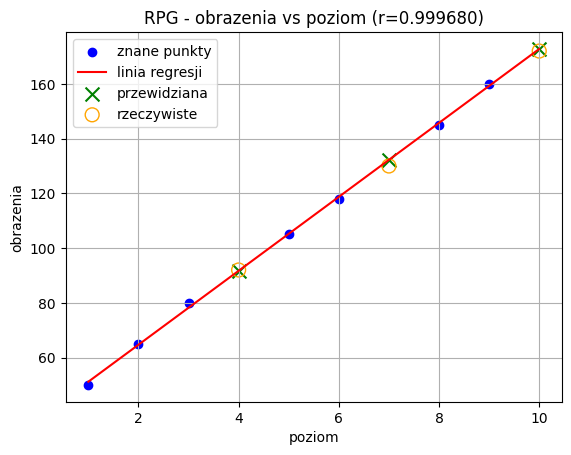

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

x = np.arange(1,11,dtype=float)
y_true = np.array([50, 65, 80, 92, 105, 118, 130, 145, 160, 172])

missing = np.array([3,6,9])

known = np.setdiff1d(np.arange(len(x)),missing)

a,b = np.polyfit(x[known],y_true[known],1)

Y_pred = a*x+b

r=np.corrcoef(x[known], y_true[known])[0,1]
print(f"korelacja = {r:.4f}")
for i in missing:
  print(f"poziom{int(x[i])} : prawdziwe {y_true[i]}, przewidziane {Y_pred[i]:.2f}, roznica {Y_pred[i] - y_true[i]:.2f}")

plt.scatter(x[known], y_true[known], color="blue", label="znane punkty")
plt.plot(x,Y_pred,color="red",label="linia regresji")
plt.scatter(x[missing],Y_pred[missing],marker="x",color="green",s=100,label="przewidziana")
plt.scatter(x[missing],y_true[missing],facecolors="none", edgecolor="orange", s=100,label="rzeczywiste")
plt.title(f"RPG - obrazenia vs poziom (r={r:2f})")
plt.xlabel("poziom")
plt.ylabel("obrazenia")
plt.legend()
plt.grid()
plt.show()


======= Zadanie 2 - FPS ======
równianie: y = -9.432377049180326*x + 158.62909836065575
korelaja : -0.9969
efekty 2 : prawdziwe 140, przewidziane 139.76, roznica -0.24
efekty 5 : prawdziwe 111, przewidziane 111.47, roznica 0.47
efekty 7 : prawdziwe 94, przewidziane 92.60, roznica -1.40


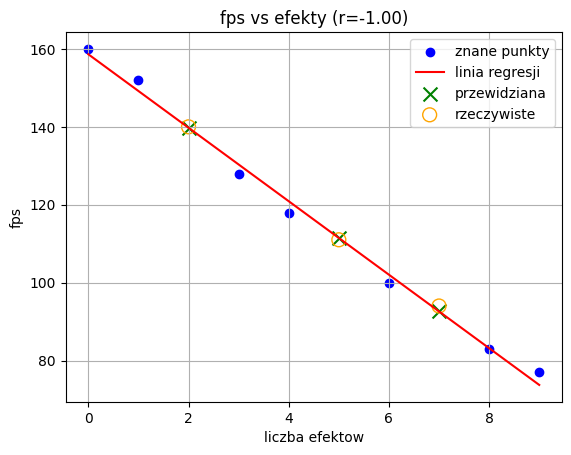

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

x = np.arange(0,10,dtype=float)
y_true = np.array([160, 152, 140, 128, 118, 111, 100, 94, 83, 77])

missing = [2,5,7]
known = [i for i in range (len(x)) if i not in missing]

res = stats.linregress(x[known],y_true[known])
y_pred = res.slope*x + res.intercept

r,p = stats.pearsonr(x[known], y_true[known])

print("======= Zadanie 2 - FPS ======")
print(f"równianie: y = {res.slope}*x + {res.intercept}")
print(f"korelaja : {r:.4f}")
for i in missing:
  print(f"efekty {int(x[i])} : prawdziwe {y_true[i]}, przewidziane {y_pred[i]:.2f}, roznica {y_pred[i]-y_true[i]:.2f}")

plt.scatter(x[known], y_true[known], color="blue", label="znane punkty")
plt.plot(x,y_pred,color="red",label="linia regresji")
plt.scatter(x[missing],y_pred[missing],marker="x",color="green",s=100,label="przewidziana")
plt.scatter(x[missing],y_true[missing],facecolors="none", edgecolor="orange", s=100,label="rzeczywiste")
plt.title(f"fps vs efekty (r={r:.2f})")
plt.xlabel("liczba efektow")
plt.ylabel("fps")
plt.legend()
plt.grid()
plt.show()

======= Zadanie 2 - FPS ======
równianie: y = -7.652213489201162*x + 549.5423820090018
korelaja : -0.3244
efekty 3 : prawdziwe 514.1120008059867, przewidziane 526.59, roznica 12.47
efekty 6 : prawdziwe 472.0584501801074, przewidziane 503.63, roznica 31.57
efekty 8 : prawdziwe 598.9358246623382, przewidziane 488.32, roznica -110.61


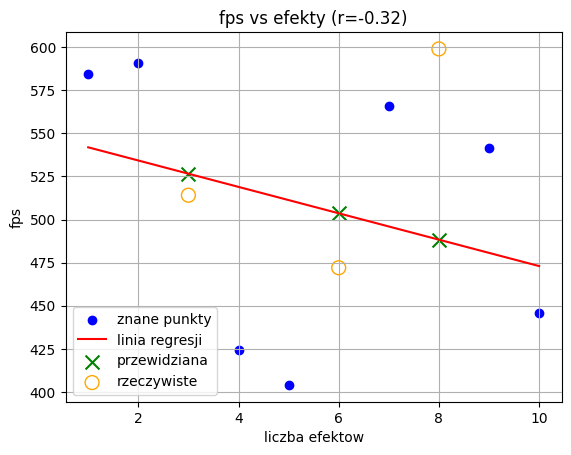

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

x = np.arange(1, 11, dtype=float)
y_true = 500 + 100 * np.sin(x)

missing = [2,5,7]
known = [i for i in range (len(x)) if i not in missing]

res = stats.linregress(x[known],y_true[known])
y_pred = res.slope*x + res.intercept

r,p = stats.pearsonr(x[known], y_true[known])

print("======= Zadanie 2 - FPS ======")
print(f"równianie: y = {res.slope}*x + {res.intercept}")
print(f"korelaja : {r:.4f}")
for i in missing:
  print(f"efekty {int(x[i])} : prawdziwe {y_true[i]}, przewidziane {y_pred[i]:.2f}, roznica {y_pred[i]-y_true[i]:.2f}")

plt.scatter(x[known], y_true[known], color="blue", label="znane punkty")
plt.plot(x,y_pred,color="red",label="linia regresji")
plt.scatter(x[missing],y_pred[missing],marker="x",color="green",s=100,label="przewidziana")
plt.scatter(x[missing],y_true[missing],facecolors="none", edgecolor="orange", s=100,label="rzeczywiste")
plt.title(f"fps vs efekty (r={r:.2f})")
plt.xlabel("liczba efektow")
plt.ylabel("fps")
plt.legend()
plt.grid()
plt.show()